In [266]:
import pandas as pd

In [267]:
xl = pd.ExcelFile("../Pomiary Z Ciepłomierzy/Aktualne v2/APEK.xlsx")

In [268]:
xl.sheet_names

['S202504']

In [269]:
df = xl.parse("S202504")

In [270]:
df

,pollub/MB,Unnamed: 1,Unnamed: 2,T1,T2,T3,T4,T5,T6,Tzew,Twew,Ua,T2-T1
0,NaT,NaN,NaN,przed zbiornikiem,za zbiornikiem,przed cyrkulacją,za cyrkulacją,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-01,01:17:27,00:17:27,15.7,15.9,46.2,50.5,"--,-","--,-",8.9,22.9,4.23,0.2
2,2025-04-01,01:27:48,00:27:48,14,13.5,33,50.2,"--,-","--,-",8.8,22.9,4.23,-0.5
3,2025-04-01,01:37:53,00:37:53,15.3,15.1,45.6,50.5,"--,-","--,-",8.8,22.9,4.24,-0.2
4,2025-04-01,01:48:08,00:48:08,16.5,16.4,46.6,50.7,"--,-","--,-",8.9,22.9,4.23,-0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13251,2025-07-04,1900-01-01 00:14:36,23:14:36,15.8,17.7,31.1,48.9,"--,-","--,-",18.6,27.8,4.24,1.9
13252,2025-07-04,1900-01-01 00:24:52,23:24:52,16.6,17.7,34.1,49.7,"--,-","--,-",18.6,27.8,4.21,1.1
13253,2025-07-04,1900-01-01 00:34:59,23:34:59,15.9,17,39.8,50.9,"--,-","--,-",18.7,27.8,4.22,1.1
13254,2025-07-04,1900-01-01 00:45:11,23:45:11,16.6,17.6,43.8,50.8,"--,-","--,-",18.5,27.7,4.23,1.0


In [271]:
df["date"] = df["pollub/MB"]

In [272]:
df["time"] = df["Unnamed: 1"]

In [273]:
df

,pollub/MB,Unnamed: 1,Unnamed: 2,T1,T2,T3,T4,T5,T6,Tzew,Twew,Ua,T2-T1,date,time
0,NaT,NaN,NaN,przed zbiornikiem,za zbiornikiem,przed cyrkulacją,za cyrkulacją,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
1,2025-04-01,01:17:27,00:17:27,15.7,15.9,46.2,50.5,"--,-","--,-",8.9,22.9,4.23,0.2,2025-04-01,01:17:27
2,2025-04-01,01:27:48,00:27:48,14,13.5,33,50.2,"--,-","--,-",8.8,22.9,4.23,-0.5,2025-04-01,01:27:48
3,2025-04-01,01:37:53,00:37:53,15.3,15.1,45.6,50.5,"--,-","--,-",8.8,22.9,4.24,-0.2,2025-04-01,01:37:53
4,2025-04-01,01:48:08,00:48:08,16.5,16.4,46.6,50.7,"--,-","--,-",8.9,22.9,4.23,-0.1,2025-04-01,01:48:08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13251,2025-07-04,1900-01-01 00:14:36,23:14:36,15.8,17.7,31.1,48.9,"--,-","--,-",18.6,27.8,4.24,1.9,2025-07-04,1900-01-01 00:14:36
13252,2025-07-04,1900-01-01 00:24:52,23:24:52,16.6,17.7,34.1,49.7,"--,-","--,-",18.6,27.8,4.21,1.1,2025-07-04,1900-01-01 00:24:52
13253,2025-07-04,1900-01-01 00:34:59,23:34:59,15.9,17,39.8,50.9,"--,-","--,-",18.7,27.8,4.22,1.1,2025-07-04,1900-01-01 00:34:59
13254,2025-07-04,1900-01-01 00:45:11,23:45:11,16.6,17.6,43.8,50.8,"--,-","--,-",18.5,27.7,4.23,1.0,2025-07-04,1900-01-01 00:45:11


In [274]:
df = df.iloc[556:]

In [275]:
from datetime import datetime

In [276]:
df["time2"] = df["time"].map(lambda x : x.time() if isinstance(x, datetime) else x  )

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\533609718.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [277]:
df["original_time"] = df["Unnamed: 2"].map(lambda x : x.time() if isinstance(x, datetime) else x  )

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\2552005080.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [278]:

# Condition: time2 occurs earlier in the day than original_time
mask = df['time2'] < df['original_time']

df["date_fixed"] = df["date"]

# Add 1 day where condition is met
df.loc[mask, 'date_fixed'] = df.loc[mask, 'date'] + pd.Timedelta(days=1)

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\3509041084.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [279]:
df["ts"] = pd.to_datetime(df["date_fixed"].astype("str") + " " + df["time2"].astype("str"))

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\1077271229.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [280]:
df

,pollub/MB,Unnamed: 1,Unnamed: 2,T1,T2,T3,T4,T5,T6,Tzew,Twew,Ua,T2-T1,date,time,time2,original_time,date_fixed,ts
556,2025-04-05,01:01:21,00:01:21,15.8,43,48.9,54.8,"--,-","--,-",12.2,25.3,4.24,27.2,2025-04-05,01:01:21,01:01:21,00:01:21,2025-04-05,2025-04-05 01:01:21
557,2025-04-05,01:11:31,00:11:31,16.3,42.1,47.9,54.9,"--,-","--,-",12.8,25.3,4.19,25.8,2025-04-05,01:11:31,01:11:31,00:11:31,2025-04-05,2025-04-05 01:11:31
558,2025-04-05,01:21:42,00:21:42,16.6,41.3,47.8,54.8,"--,-","--,-",12.5,25.3,4.24,24.7,2025-04-05,01:21:42,01:21:42,00:21:42,2025-04-05,2025-04-05 01:21:42
559,2025-04-05,01:31:52,00:31:52,17.4,40.5,49.1,55,"--,-","--,-",12.5,25.3,4.23,23.1,2025-04-05,01:31:52,01:31:52,00:31:52,2025-04-05,2025-04-05 01:31:52
560,2025-04-05,01:42:08,00:42:08,17.8,39.9,48.9,54.9,"--,-","--,-",12.6,25.3,4.23,22.1,2025-04-05,01:42:08,01:42:08,00:42:08,2025-04-05,2025-04-05 01:42:08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13251,2025-07-04,1900-01-01 00:14:36,23:14:36,15.8,17.7,31.1,48.9,"--,-","--,-",18.6,27.8,4.24,1.9,2025-07-04,1900-01-01 00:14:36,00:14:36,23:14:36,2025-07-05,2025-07-05 00:14:36
13252,2025-07-04,1900-01-01 00:24:52,23:24:52,16.6,17.7,34.1,49.7,"--,-","--,-",18.6,27.8,4.21,1.1,2025-07-04,1900-01-01 00:24:52,00:24:52,23:24:52,2025-07-05,2025-07-05 00:24:52
13253,2025-07-04,1900-01-01 00:34:59,23:34:59,15.9,17,39.8,50.9,"--,-","--,-",18.7,27.8,4.22,1.1,2025-07-04,1900-01-01 00:34:59,00:34:59,23:34:59,2025-07-05,2025-07-05 00:34:59
13254,2025-07-04,1900-01-01 00:45:11,23:45:11,16.6,17.6,43.8,50.8,"--,-","--,-",18.5,27.7,4.23,1.0,2025-07-04,1900-01-01 00:45:11,00:45:11,23:45:11,2025-07-05,2025-07-05 00:45:11


In [281]:
import pandas as pd

# Ensure ts is datetime
df['ts'] = pd.to_datetime(df['ts'])

# Identify rows where ts is not increasing
problem_idx = df.index[df['ts'] <= df['ts'].shift(1)]

# Include the previous row for context
context_idx = problem_idx.union(problem_idx - 1)

# Display a handful of cases, ordered
print(df.loc[context_idx].sort_index().head(10))


      pollub/MB           Unnamed: 1 Unnamed: 2    T1    T2    T3    T4    T5  \
4199 2025-05-01  1900-01-01 00:59:08   23:59:08  14.6  17.4  40.5  49.8  --,-   
4200 2025-05-01             01:09:23   00:09:23  14.2    17  36.9  49.8  --,-   

        T6  Tzew  Twew    Ua  T2-T1       date                 time     time2  \
4199  --,-  14.2  25.0  4.23    2.8 2025-05-01  1900-01-01 00:59:08  00:59:08   
4200  --,-  13.9  25.0  4.24    2.8 2025-05-01             01:09:23  01:09:23   

     original_time date_fixed                  ts  
4199      23:59:08 2025-05-02 2025-05-02 00:59:08  
4200      00:09:23 2025-05-01 2025-05-01 01:09:23  


C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\4262128799.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [282]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"   # try this first


C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\2636780467.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



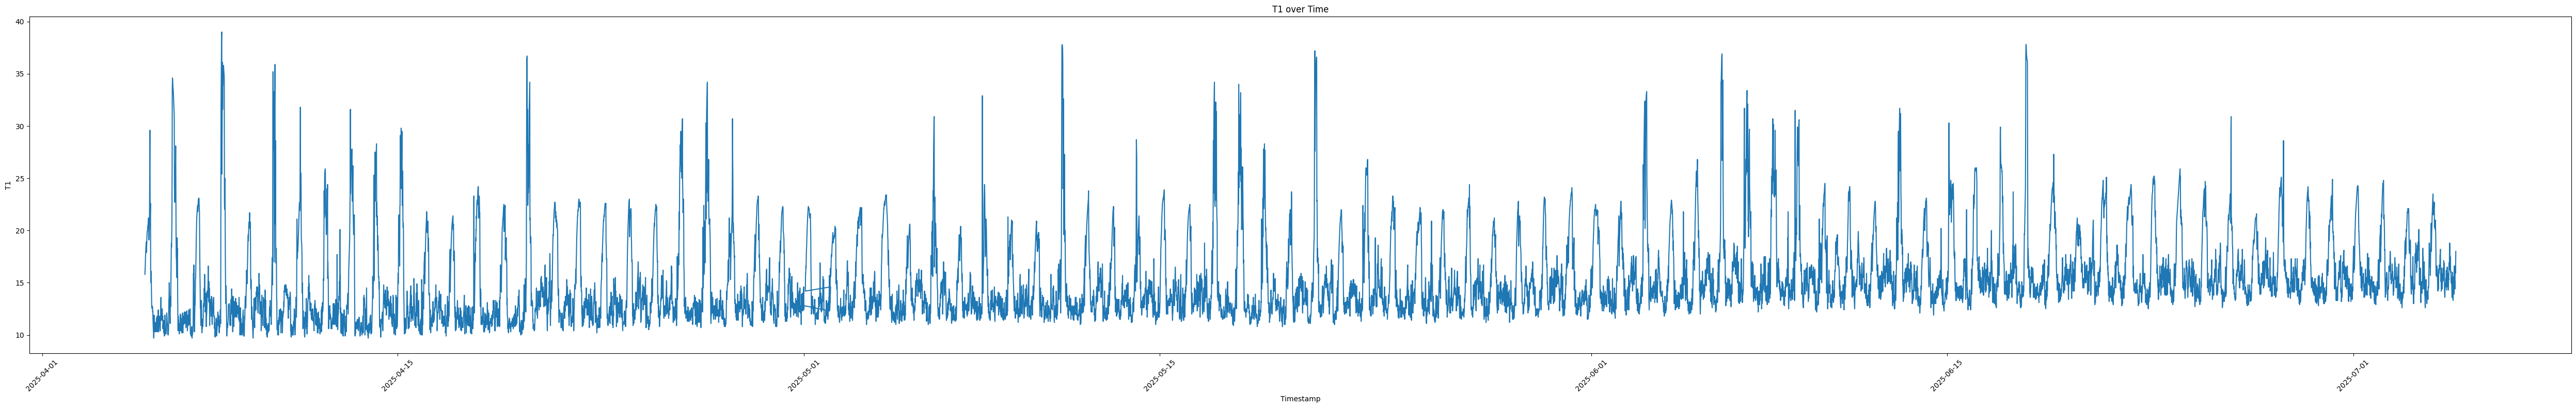

In [283]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure ts is datetime
df['ts'] = pd.to_datetime(df['ts'])

# Create the plot
plt.figure(figsize=(50, 8))
plt.plot(df['ts'], df['T1'])
plt.xlabel('Timestamp')
plt.ylabel('T1')
plt.title('T1 over Time')

# Improve x-axis formatting
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [284]:
import pandas as pd
import plotly.express as px

df['ts'] = pd.to_datetime(df['ts'])

fig = px.line(df, x='ts', y='T1', title='T1 over Time')

fig.update_xaxes(
    rangeslider_visible=True
)

fig.show()

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\2004824231.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [285]:
mask = (df["ts"] > "2025-04-15") & (df["ts"] < "2025-04-20") 

In [286]:
df[mask]

,pollub/MB,Unnamed: 1,Unnamed: 2,T1,T2,T3,T4,T5,T6,Tzew,Twew,Ua,T2-T1,date,time,time2,original_time,date_fixed,ts
1944,2025-04-14,1900-01-01 00:05:17,23:05:17,15,46.9,49.3,53.3,"--,-","--,-",14.4,25.0,4.23,31.9,2025-04-14,1900-01-01 00:05:17,00:05:17,23:05:17,2025-04-15,2025-04-15 00:05:17
1945,2025-04-14,1900-01-01 00:15:33,23:15:33,15.9,48.9,46.5,53.5,"--,-","--,-",14.5,25.2,4.23,33.0,2025-04-14,1900-01-01 00:15:33,00:15:33,23:15:33,2025-04-15,2025-04-15 00:15:33
1946,2025-04-14,1900-01-01 00:25:43,23:25:43,14.9,47.6,50.7,54,"--,-","--,-",14.1,25.3,4.23,32.7,2025-04-14,1900-01-01 00:25:43,00:25:43,23:25:43,2025-04-15,2025-04-15 00:25:43
1947,2025-04-14,1900-01-01 00:35:58,23:35:58,15.9,47.6,50,54,"--,-","--,-",13.7,25.2,4.23,31.7,2025-04-14,1900-01-01 00:35:58,00:35:58,23:35:58,2025-04-15,2025-04-15 00:35:58
1948,2025-04-14,1900-01-01 00:46:04,23:46:04,21.4,43.8,50.2,53.8,"--,-","--,-",13.4,25.2,4.22,22.4,2025-04-14,1900-01-01 00:46:04,00:46:04,23:46:04,2025-04-15,2025-04-15 00:46:04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2643,2025-04-19,23:17:51,22:17:51,14.8,47.3,45.3,50.5,"--,-","--,-",14.8,25.8,4.24,32.5,2025-04-19,23:17:51,23:17:51,22:17:51,2025-04-19,2025-04-19 23:17:51
2644,2025-04-19,23:28:08,22:28:08,11.3,50.9,50.2,50.7,"--,-","--,-",14.7,25.8,4.23,39.6,2025-04-19,23:28:08,23:28:08,22:28:08,2025-04-19,2025-04-19 23:28:08
2645,2025-04-19,23:38:15,22:38:15,11.8,42.8,43.4,50.8,"--,-","--,-",14.2,25.9,4.23,31.0,2025-04-19,23:38:15,23:38:15,22:38:15,2025-04-19,2025-04-19 23:38:15
2646,2025-04-19,23:48:32,22:48:32,13.1,36.4,47.3,51.1,"--,-","--,-",14.4,26.0,4.23,23.3,2025-04-19,23:48:32,23:48:32,22:48:32,2025-04-19,2025-04-19 23:48:32


In [287]:
import pandas as pd
import plotly.express as px

df["ts"] = pd.to_datetime(df["ts"])

df["czas"] = df["ts"]

fig = px.line(df, x="czas", y="T1", title="Temperatura przed zbiornikiem")
fig.update_xaxes(rangeslider_visible=True)

fig.write_html("plot.html", include_plotlyjs="cdn")  # smaller file; loads plotly.js from CDN


C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\1811328013.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\1811328013.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [288]:
import pandas as pd
import plotly.express as px

# Ensure datetime
df["ts"] = pd.to_datetime(df["ts"])
df["czas"] = df["ts"]

# Reshape so T1 and T2 are plotted together
df_long = df.melt(
    id_vars="czas",
    value_vars=["T1", "T2", "T3", "T4", "Tzew", "Twew", "T2-T1"], # no ua
    var_name="Sensor",
    value_name="Temperature"
)

# Plot
fig = px.line(
    df_long,
    x="czas",
    y="Temperature",
    color="Sensor",
    title="Temperatura przed zbiornikiem",
    labels={
        "czas": "Czas",
        "Temperature": "T [°C]"
    }
)

fig.update_xaxes(rangeslider_visible=True)

# Save as interactive HTML
fig.write_html("plot.html", include_plotlyjs="cdn")


C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\242138955.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\242138955.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [289]:
xl_belimo = pd.ExcelFile("../Pomiary Z Ciepłomierzy/Aktualne v2/Belimo co 1 min.xlsx")

In [290]:
xl_belimo.sheet_names

['Belimo']

In [291]:
df_belimo = xl_belimo.parse("Belimo")

In [292]:
df_belimo.columns

Index(['Data', 'Godzina', 'Przepływ, m3/h', '2303: AbsoluteWaterFlow_m3/sec',
       'Przepływ, %', 'T1, st.C', '2309: ExternalTemperatureSensorT1_K',
       'Moc, W', 'T2, st.C', '2310: IntegratedTemperatureSensorT2_K',
       'DeltaT, K', '15: AnalogInput', 'Energia T1, GJ',
       '2306: HeatingEnergyRegister_Joule', 'Energia T2, GJ',
       '2305: CoolingEnergyRegister_Joule', 'Objętość V, m3',
       '202: SelectedMeterRegisterType_0_CertifiedRegister_1_Lifetime',
       'Stężenie glikolu, %',
       '453: Medium_0_Water_1_PropyleneGlycol_2_EthyleneGlycol_3_AntifrogenL_4_AntifrogenN_5_DownCal200_6_DownCall100',
       '40004: Installation_Position_0_Device_in_supply_1_Device_in_return',
       '110: MasterDeviceErrorStatus_Bit0_No_Communication_Bit1_Gear_Disengaged_Bit2_Actuator_Cannot_Move_Bit3_Reverse_Flow_Bit4_Flow_Setpoint_Not_Reached_Bit5_Flow_With_Closed_Valve_Bit6_Flow_Actual_Exceeds_Flow_Nominal_Bit7_Flow_Measurement_Error_Bit8_Remote_Temperature_Error_Bit9_Flowbody_temper

In [293]:
df_belimo["czas"] = df_belimo["Data"].astype("str") + " " + df_belimo["Godzina"].astype("str")

In [294]:
df_belimo[["czas", "Data", "Energia T1, GJ"]].groupby("Data")

In [295]:
df_dobowe_zuzycie_ciepla = df_belimo.loc[df_belimo.groupby("Data")["czas"].idxmin()]

In [296]:
df_belimo["czas"]

0         2025-04-05 00:00:03
1         2025-04-05 00:01:03
2         2025-04-05 00:02:04
3         2025-04-05 00:03:04
4         2025-04-05 00:04:05
                 ...         
128851    2025-07-04 11:57:15
128852    2025-07-04 11:58:15
128853    2025-07-04 11:59:15
128854    2025-07-04 12:00:15
128855    2025-07-04 12:01:15
Name: czas, Length: 128856, dtype: object

In [297]:
xl_kamstrup6 = pd.ExcelFile("../Pomiary Z Ciepłomierzy/Aktualne v2/Kamstrup 206.xlsx")

In [298]:
xl_kamstrup6.sheet_names

['Sheet1']

In [299]:
df_kamstrup6 = xl_kamstrup6.parse("Sheet1") 

In [300]:
df_kamstrup6

,Numer klienta,85349206,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Data,Energia cieplna (E1) [GJ],Energia chłodu (E3) [GJ],A1 [GJ],A2 [GJ],TA2- [GJ],TA3 [GJ],TA4- [GJ],V1 [m3],V2 [m3],...,M1 [ton],M2 [ton],Kod info,Kod informacyjny (binarny),t1 śr. (Godzina) [C],t2 śr. (Godzina) [C],t3 śr. (Godzina) [C],P1 śr. (Godzina) [bar],P2 śr. (Godzina) [bar],Dane jakości
2,2025-04-01 00:00:00,1.07,0.06,2.61,2.17,0,0,0,445.79,0,...,440.83,0,00000000,0000000000,23.1,22.47,185,0,0,000
3,2025-04-01 01:00:01,1.07,0.06,2.61,2.17,0,0,0,445.79,0,...,440.83,0,00000000,0000000000,23.21,22.62,185,0,0,000
4,2025-04-01 02:00:00,1.07,0.06,2.61,2.17,0,0,0,445.79,0,...,440.83,0,00000000,0000000000,23.26,22.64,185,0,0,000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,2025-07-05 19:00:00,11.07,0.06,14.34,2.17,0,0,0,558.16,0,...,552.94,0,00000000,0000000000,34.96,28.13,185,0,0,000
2189,2025-07-05 20:00:00,11.07,0.06,14.34,2.17,0,0,0,558.16,0,...,552.94,0,00000000,0000000000,31.64,28.62,185,0,0,000
2190,2025-07-05 21:00:00,11.07,0.06,14.34,2.17,0,0,0,558.16,0,...,552.94,0,00000000,0000000000,30.16,28.56,185,0,0,000
2191,2025-07-05 22:00:00,11.07,0.06,14.34,2.17,0,0,0,558.16,0,...,552.94,0,00000000,0000000000,29.28,28.3,185,0,0,000


In [301]:
df_kamstrup6["czas"] =  df_kamstrup6["Numer klienta"]

In [302]:
df_kamstrup6 = df_kamstrup6.iloc[2:]

In [303]:
df_kamstrup6["czas"]

2       2025-04-01 00:00:00
3       2025-04-01 01:00:01
4       2025-04-01 02:00:00
5       2025-04-01 03:00:00
6       2025-04-01 04:00:00
               ...         
2188    2025-07-05 19:00:00
2189    2025-07-05 20:00:00
2190    2025-07-05 21:00:00
2191    2025-07-05 22:00:00
2192    2025-07-05 23:00:00
Name: czas, Length: 2191, dtype: object

In [304]:
df_kamstrup6 = df_kamstrup6[(df_kamstrup6["czas"] > pd.Timestamp("2025-04-05 0:00")) & (df_kamstrup6["czas"] < pd.Timestamp("2025-07-04 23:59"))]

In [305]:
xl_kamstrup7 = pd.ExcelFile("../Pomiary Z Ciepłomierzy/Aktualne v2/Kamstrup 207.xlsx")

In [306]:
xl_kamstrup7.sheet_names

['Sheet1 (2)', 'Sheet1']

In [307]:
df_kamstrup7 = xl_kamstrup7.parse('Sheet1 (2)')

In [308]:
df_kamstrup7["czas"] =  df_kamstrup7["Numer klienta"]

In [309]:
df_kamstrup7  = df_kamstrup7.iloc[2:]

In [310]:
df_kamstrup7

,Numer klienta,85349207,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,czas
2,2025-04-01 00:00:07,0.92,0.02,8.79,0.07,0,0,0,91.84,0,...,0,00000000,0000000000,21.03,19.49,185,0,0,000,2025-04-01 00:00:07
3,2025-04-01 01:00:08,0.92,0.02,8.8,0.07,0,0,0,91.92,0,...,0,00000000,0000000000,20.49,19.21,185,0,0,000,2025-04-01 01:00:08
4,2025-04-01 02:00:07,0.92,0.02,8.81,0.07,0,0,0,92,0,...,0,00000000,0000000000,21.19,20.07,185,0,0,000,2025-04-01 02:00:07
5,2025-04-01 03:00:07,0.92,0.02,8.81,0.07,0,0,0,92,0,...,0,00000000,0000000000,21.84,20.66,185,0,0,000,2025-04-01 03:00:07
6,2025-04-01 04:00:07,0.92,0.02,8.82,0.07,0,0,0,92.08,0,...,0,00000000,0000000000,22.76,20.89,185,0,0,000,2025-04-01 04:00:07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2191,2025-07-05 19:00:07,13.56,0.04,35.05,1.36,0,0,0,703.28,0,...,0,00000000,0000000000,36.68,38.21,185,0,0,000,2025-07-05 19:00:07
2192,2025-07-05 20:00:07,13.56,0.04,35.05,1.36,0,0,0,703.28,0,...,0,00000000,0000000000,29.83,31.59,185,0,0,000,2025-07-05 20:00:07
2193,2025-07-05 21:00:07,13.56,0.04,35.05,1.36,0,0,0,703.33,0,...,0,00000000,0000000000,23.36,24.34,185,0,0,000,2025-07-05 21:00:07
2194,2025-07-05 22:00:07,13.56,0.04,35.06,1.36,0,0,0,703.38,0,...,0,00000000,0000000000,22.41,23.02,185,0,0,000,2025-07-05 22:00:07


In [311]:
df_kamstrup7 = df_kamstrup7[(df_kamstrup7["czas"] > pd.Timestamp("2025-04-05 0:00")) & (df_kamstrup7["czas"] < pd.Timestamp("2025-07-04 23:59"))]

In [521]:
xl_pec = pd.ExcelFile("../Pomiary Z Ciepłomierzy/Aktualne v2/Ciepłomierz główny PECu.xlsx")

In [522]:
xl_pec.sheet_names

['Ciepłomierz główny PECu']

In [523]:
df_pec = xl_pec.parse('Ciepłomierz główny PECu')

In [524]:
df_pec["czas"] = df_pec["Data odczytu"]

In [525]:
df_pec["T1"] = df_pec["Temperatura zasilania [°C]"].str.replace(",", ".", regex=False)

In [526]:
df_pec["T2"] = df_pec["Temperatura powrotu [°C]"].str.replace(",", ".", regex=False)

In [527]:
df_pec["T1-T2"] = df_pec["Różnica temperatur [°C]"].str.replace(",", ".", regex=False)

In [ ]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots

# ---------- Prepare data ----------
df["ts"] = pd.to_datetime(df["ts"])
df["czas"] = df["ts"]
df_belimo["czas"] = pd.to_datetime(df_belimo["czas"])

df_long = df.melt(
    id_vars="czas",
    value_vars=["T1", "T2", "T3", "T4", "Tzew", "Twew", "T2-T1"],
    var_name="Sensor",
    value_name="Temperature",
)

df_belimo_temp = df_belimo.melt(
    id_vars="czas",
    value_vars=["T1, st.C", "T2, st.C"],
    var_name="Sensor",
    value_name="Temperature",
)

df_belimo_energia = df_belimo.melt(
    id_vars="czas",
    value_vars=["Energia T1, GJ", "Energia T2, GJ"],
    var_name="Sensor",
    value_name="Energia",
)

df_pec_temp = df_pec.melt(
    id_vars="czas",
    value_vars=["T1", "T2", "T1-T2"],
    var_name="Sensor",
    value_name="Temperature",
)

plots = [
    dict(
        title="APEK - Temperatura [°C]",
        fig=px.line(df_long, x="czas", y="Temperature", color="Sensor"),
        y_title="°C",
        showlegend=True,   # ✅ keep legend
        legendgroup="APEK",  # helps organization
    ),
    dict(
        title="Kamstrup - Energia Cieplna [GJ]",
        fig=None,                # we'll add traces manually
        y_title="GJ",
        showlegend=True,
    ),

    dict(
        title="Kamstrup - Objętość [m³]",
        fig=None,                # we'll add traces manually
        y_title="m³",
        showlegend=True,
    ),

    dict(
        title="Kamstrup - Temperatura [°C]",
        fig=None,                # we'll add traces manually
        y_title="°C",
        showlegend=True,
    ),
    dict(
        title="Belimo — Przepływ [m³/h]",
        fig=px.line(df_belimo, x="czas", y="Przepływ, m3/h"),
        y_title="m³/h",
        showlegend=False,  # hide legend
    ),
    dict(
        title="Belimo — Przepływ [%]",
        fig=px.line(df_belimo, x="czas", y="Przepływ, %"),
        y_title="%",
        showlegend=False,  # hide legend
    ),
    dict(
        title="Belimo — Temperatura [°C]",
        fig=px.line(df_belimo_temp, x="czas", y="Temperature", color="Sensor"),
        y_title="°C",
        showlegend=True,    # ✅ keep legend
        legendgroup="Belimo",
    ),
    dict(
        title="Belimo — Moc [W]",
        fig=px.line(df_belimo, x="czas", y="Moc, W"),
        y_title="W",
        showlegend=False,  # hide legend
    ),
    dict(
        title="Belimo — Delta T [K]",
        fig=px.line(df_belimo, x="czas", y='DeltaT, K'),
        y_title="K",
        showlegend=False,  # hide legend
    ),
    dict(
        title="Belimo — Energia [GJ]",
        fig=px.line(df_belimo_energia, x="czas", y="Energia", color="Sensor"),
        y_title="GJ",
        showlegend=True,    # ✅ keep legend
        legendgroup="BelimoEnergia",
    ),
    
    dict(
        title="Belimo — Objętość V [m³]",
        fig=px.line(df_belimo, x="czas", y='Objętość V, m3'),
        y_title="m³",
        showlegend=False,  # hide legend
    ), 
    
    dict(
        title="PEC — Objętość V [m³]",
        fig=px.line(df_pec, x="czas", y='Objętość [m3]'),
        y_title="m³",
        showlegend=False,  # hide legend
    ),

    dict(
        title="PEC — Przepływ [dm³/h]",
        fig=px.line(df_pec, x="czas", y='Przepływ [l/h]'),
        y_title="dm³/h",
        showlegend=False,  # hide legend
    ),

    dict(
        title="PEC — Moc [kW]",
        fig=px.line(df_pec, x="czas", y='Moc [kW]'),
        y_title="kW",
        showlegend=False,  # hide legend
    ),
    dict(
        title="PEC - Temperatura [°C]",
        fig=px.line(df_pec_temp, x="czas", y="Temperature", color="Sensor"),
        y_title="°C",
        showlegend=True,   # ✅ keep legend
        legendgroup="PEC",  # helps organization
    ),
]

belimo_colors = {
    "T1, st.C": "#d62728",
    "T2, st.C": "#1f77b4",
}





rows = len(plots) 

fig = make_subplots(
    rows=rows,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.02,
    row_heights=[0.88 / len(plots)] * len(plots),
    subplot_titles=[p["title"] for p in plots],
)

for i, p in enumerate(plots, start=1):
    
    # 🔹 special case: Kamstrup subplot (last row)
    if p["title"] == "Kamstrup - Energia Cieplna [GJ]":
        fig.add_scatter(
            x=df_kamstrup6["czas"],
            y=df_kamstrup6[85349206],
            mode="lines",
            name="Kamstrup 206",
            legendgroup=p["title"],
            legendgrouptitle=dict(text=p["title"]),
            row=i, col=1,
        )
    
        fig.add_scatter(
            x=df_kamstrup7["czas"],
            y=df_kamstrup7[85349207],
            mode="lines",
            name="Kamstrup 207",
            legendgroup=p["title"],
            # title only needs to be on one trace, but harmless if repeated
            legendgrouptitle=dict(text=p["title"]),
            row=i, col=1,
        )
    
        fig.update_yaxes(title_text=p["y_title"], row=i, col=1)

        continue  # skip normal px-figure handling

     # 🔹 special case: Kamstrup subplot (last row)
    if p["title"] == "Kamstrup - Objętość [m³]":
        fig.add_scatter(
            x=df_kamstrup6["czas"],
            y=df_kamstrup6["Unnamed: 8"],
            mode="lines",
            name="Kamstrup 206",
            legendgroup=p["title"],
            legendgrouptitle=dict(text=p["title"]),
            row=i, col=1,
        )
    
        fig.add_scatter(
            x=df_kamstrup7["czas"],
            y=df_kamstrup7["Unnamed: 8"],
            mode="lines",
            name="Kamstrup 207",
            legendgroup=p["title"],
            # title only needs to be on one trace, but harmless if repeated
            legendgrouptitle=dict(text=p["title"]),
            row=i, col=1,
        )
    
        fig.update_yaxes(title_text=p["y_title"], row=i, col=1)

        continue  # skip normal px-figure handling

     # 🔹 special case: Kamstrup subplot (last row)
    if p["title"] == "Kamstrup - Temperatura [°C]":
        fig.add_scatter(
            x=df_kamstrup6["czas"],
            y=df_kamstrup6["Unnamed: 18"],
            mode="lines",
            name="Kamstrup 206 - T1",
            legendgroup=p["title"],
            legendgrouptitle=dict(text=p["title"]),
            row=i, col=1,
        )

        fig.add_scatter(
            x=df_kamstrup6["czas"],
            y=df_kamstrup6["Unnamed: 19"],
            mode="lines",
            name="Kamstrup 206 - T2",
            legendgroup=p["title"],
            legendgrouptitle=dict(text=p["title"]),
            row=i, col=1,
        )
    
        fig.add_scatter(
            x=df_kamstrup7["czas"],
            y=df_kamstrup7["Unnamed: 18"],
            mode="lines",
            name="Kamstrup 207 - T1",
            legendgroup=p["title"],
            # title only needs to be on one trace, but harmless if repeated
            legendgrouptitle=dict(text=p["title"]),
            row=i, col=1,
        )

        fig.add_scatter(
            x=df_kamstrup7["czas"],
            y=df_kamstrup7["Unnamed: 19"],
            mode="lines",
            name="Kamstrup 207 - T2",
            legendgroup=p["title"],
            # title only needs to be on one trace, but harmless if repeated
            legendgrouptitle=dict(text=p["title"]),
            row=i, col=1,
        )
    
        fig.update_yaxes(title_text=p["y_title"], row=i, col=1)

        continue  # skip normal px-figure handling
    
    for tr in p["fig"].data:
        tr.showlegend = bool(p.get("showlegend", True))

        # ---- Belimo temperature subplot ----
        if  p["title"] == "Belimo — Temperatura [°C]":
            original = tr.name  # "T1, st.C" / "T2, st.C"

            # keep unique, clickable legend items
            tr.name = original.replace(", st.C", "")

            # group legend with a header
            tr.legendgroup = "BelimoTemp"
            tr.legendgrouptitle = dict(text= p["title"])

            # fixed colors
            tr.line.color = belimo_colors.get(original)

            
        # ---- Belimo energia subplot ----
        if p["title"]  == "Belimo — Energia [GJ]":
            original = tr.name  # "T1, st.C" / "T2, st.C"

            # keep unique, clickable legend items
            tr.name = original.replace(", st.C", "")

            # group legend with a header
            tr.legendgroup = "BelimoEnergia"
            tr.legendgrouptitle = dict(text= p["title"])

            # fixed colors
            tr.line.color = belimo_colors.get(original)

        if p["title"] == "APEK - Temperatura [°C]":
            original = tr.name  # "T1, st.C" / "T2, st.C"

            # keep unique, clickable legend items
            tr.name = original.replace(", st.C", "")

            # group legend with a header
            tr.legendgroup = "APEK"
            tr.legendgrouptitle = dict(text= p["title"])

        
        if p["title"] == "PEC - Temperatura [°C]":
            original = tr.name  # "T1, st.C" / "T2, st.C"

            # keep unique, clickable legend items
            tr.name = original.replace(", st.C", "")

            # group legend with a header
            tr.legendgroup = "PEC"
            tr.legendgrouptitle = dict(text= p["title"])

        fig.add_trace(tr, row=i, col=1)

    fig.update_yaxes(
        title_text=p.get("y_title", ""),
        showticklabels=True,
        automargin=True,
        row=i, col=1
    )
        
fig.update_layout(
    title="",
    height=300 * rows,  # 🔼 bigger charts
    hovermode="x unified",
    legend_title_text="",
    legend=dict(groupclick="toggleitem"),
    margin=dict(l=70, r=15, t=25, b=35),  # 🔽 tighter margins
)


# Apply slider ONLY to the bottom shared x-axis
#fig.update_layout(xaxis=dict(rangeslider=dict(visible=True, thickness=0.035)))

# Give y-axes room (so labels don't get clipped)
fig.update_layout(margin=dict(l=70, r=20, t=60, b=50))

fig.update_xaxes(
    showticklabels=True,
    ticks="outside",
    tickfont=dict(size=10),
)

fig.update_xaxes(
    rangeslider=dict(
        visible=True,
        thickness=0.01,
        bgcolor="rgba(0,0,0,0)",
        borderwidth=0,
    ),
    row=rows,
    col=1,
)


fig.update_yaxes(autorange=True)
fig.update_yaxes(type="linear")

fig.update_layout(margin=dict(l=70, r=20, t=60, b=50))

fig.write_html("plot.html", include_plotlyjs="cdn")


In [ ]:
# Wstrzykuje jasny, „bootstrapowy” panel instrukcji do istniejącego pliku HTML (np. plot.html)
# Nie zmienia wykresu — dodaje tylko sekcję instrukcji na górze strony.

from pathlib import Path

PLOT_HTML_PATH = "plot.html"                 # wejściowy plik HTML
OUTPUT_HTML_PATH = "plot_z_instrukcja.html"  # wynik

INSTRUKCJA_HTML = r"""
<style>
  /* Jasne tło strony + lekko bootstrapowy wygląd */
  body{
  background:#f8f9fa !important;
  color:#212529 !important;
  font-family:
    system-ui,
    -apple-system,
    "Segoe UI",
    Roboto,
    "Helvetica Neue",
    Arial,
    "Noto Sans",
    "Liberation Sans",
    sans-serif !important;
}
  .container-ish{
    max-width: 1080px;
    margin: 16px auto 10px;
    padding: 0 16px;
  }
  .cardish{
    background:#ffffff;
    border:1px solid rgba(0,0,0,.125);
    border-radius:.5rem;
    box-shadow: 0 .125rem .25rem rgba(0,0,0,.075);
    overflow:hidden;
  }
  .cardish-header{
    padding: .75rem 1rem;
    background:#ffffff;
    border-bottom:1px solid rgba(0,0,0,.125);
    display:flex;
    align-items:center;
    justify-content:space-between;
    gap: 10px;
  }
  .cardish-title{
    margin:0;
    font-size: 1rem;
    font-weight: 600;
  }
  .badgeish{
    display:inline-block;
    padding:.25rem .5rem;
    border-radius: 999px;
    font-size: .75rem;
    border: 1px solid rgba(0,0,0,.125);
    background:#f1f3f5;
    color:#495057;
    white-space: nowrap;
  }
  .cardish-body{
    padding: 1rem;
  }
  .muted{
    color:#6c757d;
    margin: 0 0 .75rem 0;
    line-height: 1.45;
  }
  .rowish{
    display:grid;
    grid-template-columns: 1fr;
    gap: .75rem;
  }
  @media (min-width: 900px){
    .rowish{ grid-template-columns: 1fr 1fr; }
  }
  .listish{
    margin: 0;
    padding-left: 1.1rem;
  }
  .listish li{
    margin: .35rem 0;
    line-height: 1.45;
  }
  .kbdish{
    display:inline-block;
    padding: .1rem .4rem;
    border-radius: .35rem;
    border:1px solid rgba(0,0,0,.2);
    background:#f8f9fa;
    font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, "Liberation Mono","Courier New", monospace;
    font-size: .85em;
    white-space: nowrap;
  }
  .alertish{
    margin-top: .75rem;
    padding: .75rem 1rem;
    border-radius: .5rem;
    border: 1px solid rgba(13,110,253,.25);
    background: rgba(13,110,253,.08);
    color:#084298;
    line-height:1.45;
  }

  /* Akordeon (details/summary) w stylu bootstrap */
  details.accordionish > summary{
    list-style:none;
    cursor:pointer;
    user-select:none;
  }
  details.accordionish > summary::-webkit-details-marker{ display:none; }
  .chev{
    font-size: 1rem;
    color:#6c757d;
    transition: transform .15s ease-in-out;
  }
  details[open] .chev{ transform: rotate(180deg); }

  /* Trochę miejsca nad wykresem (żeby panel nie "przyklejał się") */
  .container-ish + div, .container-ish + main { margin-top: 6px; }
</style>

<div class="container-ish" id="instrukcja-obslugi">
  <details class="accordionish cardish" open>
    <summary class="cardish-header">
      <div style="display:flex;align-items:center;gap:.5rem;flex-wrap:wrap;">
        <h2 class="cardish-title">Instrukcja obsługi wykresu</h2>
        <span class="badgeish">kliknij, aby zwinąć/rozwinąć</span>
      </div>
      <span class="chev">⌄</span>
    </summary>

    <div class="cardish-body">
      <p class="muted">
        Wykres jest interaktywny. Poniżej znajdziesz krótką ściągę: jak przybliżać, przesuwać widok i sterować seriami z legendy.
      </p>

      <div class="rowish">
        <div>
          <strong>Na samym wykresie</strong>
          <ul class="listish">
            <li><b>Podgląd wartości:</b> przesuń kursor po wykresie.</li>
            <li><b>Przybliżenie (zoom):</b> kliknij i przeciągnij myszą po obszarze do powiększenia.</li>
            <li><b>Przesuwanie widoku:</b> złap wykres i przeciągnij, aby przesunąć w czasie.</li>
            <li><b>Reset widoku:</b> <span class="kbdish">podwójny klik</span> w obszar wykresu.</li>
            <li><b>Kółko myszy:</b> w wielu przypadkach przybliża/oddala (jeśli nie — użyj zoomu prostokątem).</li>
          </ul>
        </div>

        <div>
          <strong>Legenda i suwak czasu</strong>
          <ul class="listish">
            <li><b>Ukryj/pokaż serię:</b> kliknij jej nazwę w legendzie.</li>
            <li><b>Pokaż tylko jedną serię:</b> <span class="kbdish">dwuklik</span> na nazwie w legendzie.</li>
            <li><b>Przywróć wszystkie serie:</b> ponownie <span class="kbdish">dwuklik</span> (albo reset widoku).</li>
            <li><b>Suwak czasu:</b> przeciągnij lewy/prawy uchwyt, aby ustawić zakres; przeciągnij zaznaczenie, aby przesunąć zakres.</li>
          </ul>
        </div>
      </div>

      <div class="alertish">
        Wskazówka: jeśli przeciąganie „zamiast przesuwać” robi przybliżenie (lub odwrotnie),
        skorzystaj z ikon w prawym górnym rogu wykresu (tryb przesuwania / tryb przybliżania).
      </div>
    </div>
  </details>
</div>
"""

def inject_panel_into_html(input_path: str, output_path: str, injection_html: str) -> None:
    html = Path(input_path).read_text(encoding="utf-8")

    # zabezpieczenie przed podwójnym wstrzyknięciem
    if 'id="instrukcja-obslugi"' in html:
        Path(output_path).write_text(html, encoding="utf-8")
        return

    lower = html.lower()
    body_idx = lower.find("<body")
    if body_idx == -1:
        raise ValueError("Nie znaleziono tagu <body> w pliku HTML.")

    body_end = lower.find(">", body_idx)
    if body_end == -1:
        raise ValueError("Tag <body> wygląda na uszkodzony (brak '>').")

    new_html = html[:body_end + 1] + "\n" + injection_html + "\n" + html[body_end + 1:]
    Path(output_path).write_text(new_html, encoding="utf-8")

inject_panel_into_html(PLOT_HTML_PATH, OUTPUT_HTML_PATH, INSTRUKCJA_HTML)
print(f"Zapisano: {OUTPUT_HTML_PATH}")


In [ ]:
df_dobowe_zuzycie_ciepla["E"] = df_dobowe_zuzycie_ciepla["Energia T1, GJ"] 

In [ ]:
df_dobowe_zuzycie_ciepla[["Data", "E"]]

In [ ]:
df_dobowe_zuzycie_ciepla["Ep"] = df_dobowe_zuzycie_ciepla["E"].shift(1)

In [ ]:
df_dobowe_zuzycie_ciepla["Eo"] = df_dobowe_zuzycie_ciepla["E"] 

In [ ]:
df_dobowe_zuzycie_ciepla["Ed"] = df_dobowe_zuzycie_ciepla["Eo"] - df_dobowe_zuzycie_ciepla["Ep"]

In [ ]:
df_dobowe_zuzycie_ciepla[["Data", "czas", "Ed", "Eo", "Ep"]]

In [ ]:
import plotly.express as px

fig = px.bar(
    df_dobowe_zuzycie_ciepla,
    x="Data",
    y="Ed",
    title="Dobowe zużycie ciepła [GJ]",
    labels={
        "Data": "Data",
        "Ed": "Dobowe zużycie ciepła Ed [GJ]"
    }
)

fig.update_layout(
    height=500,
    hovermode="x unified",
    margin=dict(l=70, r=20, t=60, b=50),
)

fig.update_xaxes(tickangle=-45)

fig.write_html("dobowe_zuzycie_ciepla.html", include_plotlyjs="cdn")

In [ ]:
df_dobowe_zuzycie_ciepla[["Data", "czas", "Ed", "Eo", "Ep"]]

In [ ]:
df_dobowe_zuzycie_ciepla["Day"] = pd.to_datetime(df_dobowe_zuzycie_ciepla["Data"]).dt.day
df_czwartego_dnia_miesiaca = df_dobowe_zuzycie_ciepla[df_dobowe_zuzycie_ciepla["Day"] == 4]
df_czwartego_dnia_miesiaca[["Data", "czas", "Ed", "Eo", "Ep"]]

In [ ]:
df_belimo_czas_dt = pd.to_datetime(df_belimo["czas"])
df_belimo["Day"] = df_belimo_czas_dt.dt.day
df_belimo["Hour"] = df_belimo_czas_dt.dt.hour
df_belimo["Date"] = df_belimo_czas_dt.dt.date

# Filtruj dla 5go dnia miesiaca o polnocy (pierwszy wpis kazdego 5go dnia)
df_fifth_day_midnight = df_belimo[(df_belimo["Day"] == 5) & (df_belimo["Hour"] == 0)].drop_duplicates(subset=["Date"], keep="first").copy()

# Sprawdz czy istnieje wpis dla 2025-07-05
july_5_exists = any(df_fifth_day_midnight["Date"] == pd.to_datetime("2025-07-05").date())

# Jesli nie istnieje 2025-07-05 o polnocy, dodaj ostatni wpis z 2025-07-04 (12:01)
if not july_5_exists:
    last_july_4 = df_belimo[df_belimo["Date"] == pd.to_datetime("2025-07-04").date()]
    if not last_july_4.empty:
        # Weź ostatni wiersz z 2025-07-04
        last_entry = last_july_4.iloc[-1:].copy()
        last_entry["Date"] = pd.to_datetime("2025-07-05").date()
        df_fifth_day_midnight = pd.concat([df_fifth_day_midnight, last_entry], ignore_index=True)


In [ ]:

df_fifth_day_midnight["Ek"] = df_fifth_day_midnight["Energia T1, GJ"]
df_fifth_day_midnight["En"] = df_fifth_day_midnight["Ek"].shift(1)

In [ ]:
df_fifth_day_midnight["Em"] = df_fifth_day_midnight["Ek"] - df_fifth_day_midnight["En"] 

In [ ]:
df_fifth_day_midnight[["Data", "Em"]]

In [ ]:
import plotly.express as px

# Dodaj kolumnę z nazwą poprzedniego miesiąca
df_fifth_day_midnight["Miesiąc"] = (pd.to_datetime(df_fifth_day_midnight["Data"]) - pd.DateOffset(months=1)).dt.strftime("%B %Y")

# Usuń pierwszy wiersz (kwiecień - nie ma poprzedniego miesiąca)
df_miesieczne = df_fifth_day_midnight.iloc[1:].copy()

fig = px.bar(
    df_miesieczne,
    x="Miesiąc",
    y="Em",
    title="Miesięczne zużycie ciepła [GJ]",
    labels={
        "Miesiąc": "Miesiąc",
        "Em": "Miesięczne zużycie ciepła Em [GJ]"
    }
)

fig.update_layout(
    height=500,
    hovermode="x unified",
    margin=dict(l=70, r=20, t=60, b=50),
)

fig.update_xaxes(tickangle=-45)

fig.write_html("miesieczne_zuzycie_ciepla.html", include_plotlyjs="cdn")

In [ ]:
# Oblicz różnicę między maksymalną a minimalną wartością energii w całym df_belimo
Es = df_belimo["Energia T1, GJ"].max() - df_belimo["Energia T1, GJ"].min()
Es

In [ ]:
import plotly.express as px

# Wykres jednowartościowy dla Es
df_es = pd.DataFrame({"Sezon": ["Sezon"], "Es": [Es]})

fig = px.bar(
    df_es,
    x="Sezon",
    y="Es",
    title="Zużycie ciepła sezonowe [GJ]",
    labels={"Sezon": "Sezon kwiecień-lipiec 2025", "Es": "Sezonowe zużycie ciepła Es [GJ]"}
)

fig.update_layout(
    height=400,
    hovermode="x unified",
    margin=dict(l=70, r=20, t=60, b=50),
)

#fig.update_xaxes(title_text="Sezon")

fig.write_html("sezon_es.html", include_plotlyjs="cdn")

In [440]:
df_belimo["T1"] = df_belimo["T1, st.C"]

In [441]:
df_belimo["T2"] = df_belimo["T2, st.C"]

In [442]:
df_belimo["Tsr"] = (df_belimo["T1"] + df_belimo["T2"]) / 2

In [445]:
filtered_df = df_belimo[df_belimo["Przepływ, m3/h"] > 0]

filtered_df['czas'] = pd.to_datetime(filtered_df['czas'])

hourly_df = filtered_df.set_index('czas').resample('H')['Tsr'].mean().reset_index()

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\3715748179.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\3715748179.py:5: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [ ]:
import plotly.express as px



fig = px.bar(
    hourly_df,
    x="czas",
    y="Tsr",
    title="Temperatura czynnika po stronie sieciowej (średnia godzinowa) podczas pracy pompy ciepła",
    labels={"czas": "Czas", "Tsr": "Tśr [°C]"},
)

fig.update_layout(
    height=500,
    hovermode="x unified",
    margin=dict(l=70, r=20, t=60, b=50),
)

fig.update_traces(width=3600000, marker_color="darkblue")

fig.update_xaxes(rangeslider_visible=True, tickangle=-45)

fig.write_html("temperatura_czynnika_po_stronie_sieciowej.html", include_plotlyjs="cdn")

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\3276212195.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\3276212195.py:7: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



KeyError: 'Column not found: Tsr'

In [446]:
K = 273.15

In [447]:
filtered_df["ro_w"] = 1000 - (0.00198582 * (filtered_df["Tsr"] + K + 10) * (filtered_df["Tsr"] + K - 277)**2) / (filtered_df["Tsr"] + K - 205.8)

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\2603890114.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [448]:
filtered_df[["ro_w", "Tsr"]]

,ro_w,Tsr
25,996.215027,28.0195
26,996.187848,28.1145
27,996.188564,28.1120
28,996.166189,28.1900
117,996.396435,27.3780
...,...,...
128845,995.736202,29.6540
128846,995.709755,29.7420
128847,995.685654,29.8220
128848,995.664670,29.8915


In [449]:
filtered_df["Tsr_rounded"] = filtered_df["Tsr"].round(2)

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\249230234.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [450]:
filtered_df["Tsr_rounded"]

25        28.02
26        28.11
27        28.11
28        28.19
117       27.38
          ...  
128845    29.65
128846    29.74
128847    29.82
128848    29.89
128849    29.97
Name: Tsr_rounded, Length: 28494, dtype: float64

In [451]:
filtered_df.describe()

,Data,"Przepływ, m3/h",2303: AbsoluteWaterFlow_m3/sec,"T1, st.C",2309: ExternalTemperatureSensorT1_K,"T2, st.C",2310: IntegratedTemperatureSensorT2_K,"DeltaT, K",15: AnalogInput,"Energia T1, GJ",...,Unnamed: 30,Unnamed: 31,Unnamed: 32,czas,V_niezero,T1,T2,Tsr,ro_w,Tsr_rounded
count,28494,28494.000000,28494.000000,28494.000000,28494.000000,28494.000000,28494.000000,28494.000000,28494.000000,28494.000000,...,0.0,0.0,0.0,28494,28494.0,28494.000000,28494.000000,28494.000000,28494.000000,28494.000000
mean,2025-05-13 20:36:08.035375872,1.089693,0.000303,19.567102,292.717102,14.753504,287.903504,4.916906,0.295968,7.022832,...,NaN,NaN,NaN,2025-05-14 10:34:56.337298688,1.0,19.567102,14.753504,17.160303,998.600358,17.160552
min,2025-04-05 00:00:00,0.006266,0.000002,1.551000,274.701000,-3.142000,270.008000,0.000041,0.293000,1.701349,...,NaN,NaN,NaN,2025-04-05 00:25:10,1.0,1.551000,-3.142000,-0.418000,990.157054,-0.420000
25%,2025-04-19 00:00:00,1.080914,0.000300,17.928000,291.078000,12.005000,285.155000,5.122770,0.296000,4.489112,...,NaN,NaN,NaN,2025-04-19 04:07:37.500000,1.0,17.928000,12.005000,15.005500,998.826668,15.010000
50%,2025-05-13 00:00:00,1.085116,0.000301,18.522000,291.672000,12.801000,285.951000,5.748115,0.296000,7.031290,...,NaN,NaN,NaN,2025-05-13 06:07:31,1.0,18.522000,12.801000,15.659500,999.003059,15.660000
75%,2025-06-03 00:00:00,1.090789,0.000303,19.583000,292.733000,13.947000,287.097000,6.214745,0.296000,9.625913,...,NaN,NaN,NaN,2025-06-03 20:31:01,1.0,19.583000,13.947000,16.720500,999.105319,16.720000
max,2025-07-04 00:00:00,1.491815,0.000414,44.844000,317.994000,45.267000,318.417000,8.333640,0.296000,12.051202,...,NaN,NaN,NaN,2025-07-04 11:55:15,1.0,44.844000,45.267000,45.051000,1000.000000,45.050000
std,NaN,0.037101,0.000010,4.280368,4.280368,6.307774,6.307774,2.219047,0.000308,3.003833,...,NaN,NaN,NaN,NaN,0.0,4.280368,6.307774,5.250944,1.082962,5.250967


In [452]:
df_belimo.describe()

,Data,"Przepływ, m3/h",2303: AbsoluteWaterFlow_m3/sec,"T1, st.C",2309: ExternalTemperatureSensorT1_K,"T2, st.C",2310: IntegratedTemperatureSensorT2_K,"DeltaT, K",15: AnalogInput,"Energia T1, GJ",...,Unnamed: 26,Unnamed: 27,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,V_niezero,T1,T2,Tsr
count,128856,128856.000000,128856.000000,128856.000000,128856.000000,128856.000000,128856.000000,1.288560e+05,128856.000000,128856.000000,...,0.0,4.000000,0.0,0.0,0.0,2.000000,128856.000000,128856.000000,128856.000000,128856.000000
mean,2025-05-19 15:14:22.283479296,0.240964,0.000067,26.096517,299.246517,24.521026,297.671026,1.607454e+00,0.295969,7.675340,...,NaN,64429.055286,NaN,NaN,NaN,1311.283333,0.221131,26.096517,24.521026,25.308772
min,2025-04-05 00:00:00,0.000000,0.000000,1.551000,274.701000,-3.142000,270.008000,7.358070e-07,0.293000,1.701349,...,NaN,0.221143,NaN,NaN,NaN,474.933333,0.000000,1.551000,-3.142000,-0.418000
25%,2025-04-27 00:00:00,0.000000,0.000000,25.221750,298.371750,24.443000,297.593000,9.278433e-02,0.296000,5.170148,...,NaN,21372.055286,NaN,NaN,NaN,893.108333,0.000000,25.221750,24.443000,24.843500
50%,2025-05-19 00:00:00,0.000000,0.000000,27.698000,300.848000,27.293000,300.443000,4.840450e-01,0.296000,8.230263,...,NaN,64429.000000,NaN,NaN,NaN,1311.283333,0.000000,27.698000,27.293000,27.522000
75%,2025-06-12 00:00:00,0.000000,0.000000,28.671000,301.821000,28.150000,301.300000,1.950030e+00,0.296000,10.340298,...,NaN,107486.000000,NaN,NaN,NaN,1729.458333,0.000000,28.671000,28.150000,28.397000
max,2025-07-04 00:00:00,1.491815,0.000414,44.844000,317.994000,45.267000,318.417000,8.333640e+00,0.296000,12.051202,...,NaN,128858.000000,NaN,NaN,NaN,2147.633333,1.000000,44.844000,45.267000,45.051000
std,NaN,0.452570,0.000126,4.416052,4.416052,6.248692,6.248692,2.161015e+00,0.000304,2.944069,...,NaN,60234.332857,NaN,NaN,NaN,1182.777513,0.415010,4.416052,6.248692,5.299142


In [453]:
import pandas as pd

df_interpolacja = pd.read_csv("data/interpolacja_wody.csv")

df_interpolacja

,Temperatura (°C),Cisnienie p (MPa),Gestosc ρ (kg/m³),Cieplo wlasciwe cp (kJ/(kg·K)),Przewodzenie ciepla λ·10^2 (W/(m·K)),Dyfuzyjnosc cieplna a·10^8 (m²/s),Lepkosc dynamiczna μ·10^6 (N·s/m²),Lepkosc kinematyczna ν·10^6 (m²/s),Rozszerzalnosc β·10^4 (1/K),Napiecie powierzchniowe σ·10^4 (N/m),Liczba Prandtla Pr (-)
0,0.01,0.000610,999.900000,4.212000,55.100000,13.100000,1788.000000,1.789000,-0.630000,756.400000,13.670000
1,0.02,0.000611,999.899800,4.211979,55.102302,13.100601,1787.517518,1.788517,-0.628669,756.385185,13.665846
2,0.03,0.000611,999.899600,4.211958,55.104605,13.101201,1787.035035,1.788033,-0.627337,756.370370,13.661692
3,0.04,0.000612,999.899399,4.211937,55.106907,13.101802,1786.552553,1.787550,-0.626006,756.355556,13.657538
4,0.05,0.000612,999.899199,4.211916,55.109209,13.102402,1786.070070,1.787066,-0.624675,756.340741,13.653383
...,...,...,...,...,...,...,...,...,...,...,...
9995,99.96,0.101175,958.427600,4.219952,68.298800,16.899600,282.629600,0.295124,7.517720,588.674400,1.750800
9996,99.97,0.101206,958.420700,4.219964,68.299100,16.899700,282.597200,0.295093,7.518290,588.655800,1.750600
9997,99.98,0.101238,958.413800,4.219976,68.299400,16.899800,282.564800,0.295062,7.518860,588.637200,1.750400
9998,99.99,0.101269,958.406900,4.219988,68.299700,16.899900,282.532400,0.295031,7.519430,588.618600,1.750200


In [454]:
# Lookup cw from df_interpolacja based on Tsr_rounded
cw_series = df_interpolacja.set_index('Temperatura (°C)')['Cieplo wlasciwe cp (kJ/(kg·K))']
filtered_df['cw'] = filtered_df['Tsr_rounded'].map(cw_series)

filtered_df[['Tsr_rounded', 'cw']].head()

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\42997762.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Tsr_rounded,cw
25,28.02,4.175782
26,28.11,4.175701
27,28.11,4.175701
28,28.19,4.175629
117,27.38,4.176358


In [455]:
filtered_df["Q_cwu_sr"] = (filtered_df["Przepływ, m3/h"] * filtered_df["ro_w"] * (filtered_df["T1, st.C"] - filtered_df["T2, st.C"]) * filtered_df["cw"]) / (3600 * 1000)

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\919161740.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [456]:
filtered_df[filtered_df["T1, st.C"] >  filtered_df["T2, st.C"]][["Q_cwu_sr", "Tsr", "T1, st.C", "T2, st.C", "Przepływ, m3/h"]]

,Q_cwu_sr,Tsr,"T1, st.C","T2, st.C","Przepływ, m3/h"
119,0.009584,15.1135,18.981,11.246,1.066378
120,0.006641,6.5610,9.354,3.768,1.019516
121,0.007594,7.4995,10.616,4.383,1.045325
122,0.006142,16.2505,18.700,13.801,1.079330
123,0.007716,20.2225,23.213,17.232,1.112447
...,...,...,...,...,...
128750,0.000001,27.8285,27.887,27.770,0.010742
128751,0.000050,27.4940,27.513,27.475,1.138223
128753,0.010249,14.4380,18.580,10.296,1.064484
128754,0.006951,4.7455,7.650,1.841,1.025154


In [457]:
filtered_df[filtered_df["T1, st.C"] >  filtered_df["T2, st.C"]]

,Data,Godzina,"Przepływ, m3/h",2303: AbsoluteWaterFlow_m3/sec,"Przepływ, %","T1, st.C",2309: ExternalTemperatureSensorT1_K,"Moc, W","T2, st.C",2310: IntegratedTemperatureSensorT2_K,...,Unnamed: 33,czas,V_niezero,T1,T2,Tsr,ro_w,Tsr_rounded,cw,Q_cwu_sr
119,2025-04-05,01:59:25,1.066378,0.000296,42.6553,18.981,292.131,9374.97,11.246,284.396,...,NaN,2025-04-05 01:59:25,1,18.981,11.246,15.1135,999.088776,15.11,4.186912,0.009584
120,2025-04-05,02:00:25,1.019516,0.000283,40.7809,9.354,282.504,6481.39,3.768,276.918,...,NaN,2025-04-05 02:00:25,1,9.354,3.768,6.5610,999.942792,6.56,4.198231,0.006641
121,2025-04-05,02:01:26,1.045325,0.000290,41.8133,10.616,283.766,7386.65,4.383,277.533,...,NaN,2025-04-05 02:01:26,1,10.616,4.383,7.4995,999.897296,7.50,4.196255,0.007594
122,2025-04-05,02:02:26,1.079330,0.000300,43.1735,18.700,291.850,6027.79,13.801,286.951,...,NaN,2025-04-05 02:02:26,1,18.700,13.801,16.2505,998.906391,16.25,4.186000,0.006142
123,2025-04-05,02:03:26,1.112447,0.000309,44.4981,23.213,296.363,7596.88,17.232,290.382,...,NaN,2025-04-05 02:03:26,1,23.213,17.232,20.2225,998.155926,20.22,4.182802,0.007716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128750,2025-07-04,10:15:58,0.010742,0.000003,4.29701E+-1,27.887,301.037,1.42677,27.770,300.920,...,NaN,2025-07-04 10:15:58,1,27.887,27.770,27.8285,996.269428,27.83,4.175953,0.000001
128751,2025-07-04,10:16:58,1.138223,0.000316,45.5292,27.513,300.663,49.1212,27.475,300.625,...,NaN,2025-07-04 10:16:58,1,27.513,27.475,27.4940,996.363908,27.49,4.176259,0.000050
128753,2025-07-04,10:18:58,1.064484,0.000296,42.5796,18.580,291.730,10020.5,10.296,283.446,...,NaN,2025-07-04 10:18:58,1,18.580,10.296,14.4380,999.189984,14.44,4.187448,0.010249
128754,2025-07-04,10:19:58,1.025154,0.000285,41.0064,7.650,280.800,6754.33,1.841,274.991,...,NaN,2025-07-04 10:19:58,1,7.650,1.841,4.7455,999.993641,4.75,4.202036,0.006951


In [458]:
import numpy as np

# Create filtered_df_with_nans with all rows from df_belimo, adding NaNs for calculated columns where flow <= 0
filtered_df_with_nans = df_belimo.copy()

# Initialize calculated columns with NaN
filtered_df_with_nans['Tsr'] = np.nan
filtered_df_with_nans['ro_w'] = np.nan
filtered_df_with_nans['Tsr_rounded'] = np.nan
filtered_df_with_nans['cw'] = np.nan
filtered_df_with_nans['Q_cwu_sr'] = np.nan

# Update where flow > 0
mask = filtered_df_with_nans['Przepływ, m3/h'] > 0
filtered_df_with_nans.loc[mask, ['Tsr', 'ro_w', 'Tsr_rounded', 'cw', 'Q_cwu_sr']] = filtered_df[['Tsr', 'ro_w', 'Tsr_rounded', 'cw', 'Q_cwu_sr']].values

filtered_df_with_nans = filtered_df_with_nans[filtered_df_with_nans["T1, st.C"] > filtered_df_with_nans["T2, st.C"]]

In [465]:
filtered_df[["czas", "Tsr", "T1", "T2", "Przepływ, m3/h", "Q_cwu_sr", "ro_w", "cw"]][filtered_df["T1"] > filtered_df["T2"]]

,czas,Tsr,T1,T2,"Przepływ, m3/h",Q_cwu_sr,ro_w,cw
119,2025-04-05 01:59:25,15.1135,18.981,11.246,1.066378,0.009584,999.088776,4.186912
120,2025-04-05 02:00:25,6.5610,9.354,3.768,1.019516,0.006641,999.942792,4.198231
121,2025-04-05 02:01:26,7.4995,10.616,4.383,1.045325,0.007594,999.897296,4.196255
122,2025-04-05 02:02:26,16.2505,18.700,13.801,1.079330,0.006142,998.906391,4.186000
123,2025-04-05 02:03:26,20.2225,23.213,17.232,1.112447,0.007716,998.155926,4.182802
...,...,...,...,...,...,...,...,...
128750,2025-07-04 10:15:58,27.8285,27.887,27.770,0.010742,0.000001,996.269428,4.175953
128751,2025-07-04 10:16:58,27.4940,27.513,27.475,1.138223,0.000050,996.363908,4.176259
128753,2025-07-04 10:18:58,14.4380,18.580,10.296,1.064484,0.010249,999.189984,4.187448
128754,2025-07-04 10:19:58,4.7455,7.650,1.841,1.025154,0.006951,999.993641,4.202036


In [459]:
import plotly.express as px

fig = px.line(
    filtered_df_with_nans,
    x="czas",
    y="Q_cwu_sr",
    title="Moc cieplna Q cwu śr [kW]",
    labels={"czas": "Czas", "Q_cwu_sr": "Q_cwu_sr [kW]"}
)

fig.update_layout(
    height=500,
    hovermode="x unified",
    margin=dict(l=70, r=20, t=60, b=50),
)

fig.update_xaxes(rangeslider_visible=True, tickangle=-45)

fig.write_html("q_cwu_sr_full.html", include_plotlyjs="cdn")

In [ ]:
df_kamstrup7

,Numer klienta,85349207,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,czas,T1,T2
98,2025-04-05 00:00:07,1.87,0.02,10.46,0.15,0,0,0,135.08,0,...,0000002048 - V1>qs przez więcej niż godzinę,52.64,47.68,185,0,0,000,2025-04-05 00:00:07,52.64,47.68
99,2025-04-05 01:00:07,1.87,0.02,10.46,0.15,0,0,0,135.13,0,...,0000000000,40.87,41.9,185,0,0,000,2025-04-05 01:00:07,40.87,41.9
100,2025-04-05 02:00:07,1.87,0.02,10.46,0.15,0,0,0,135.13,0,...,0000000000,29.55,31.31,185,0,0,000,2025-04-05 02:00:07,29.55,31.31
101,2025-04-05 03:00:07,1.87,0.02,10.47,0.15,0,0,0,135.18,0,...,0000000000,27.61,28.69,185,0,0,000,2025-04-05 03:00:07,27.61,28.69
102,2025-04-05 04:00:07,1.87,0.02,10.47,0.15,0,0,0,135.25,0,...,0000000000,26.68,27.54,185,0,0,000,2025-04-05 04:00:07,26.68,27.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2167,2025-07-04 19:00:07,13.5,0.04,34.87,1.35,0,0,0,699.79,0,...,0000000000,33.73,34.43,185,0,0,000,2025-07-04 19:00:07,33.73,34.43
2168,2025-07-04 20:00:07,13.51,0.04,34.89,1.35,0,0,0,700.11,0,...,0000000000,31.08,31.1,185,0,0,000,2025-07-04 20:00:07,31.08,31.1
2169,2025-07-04 21:00:07,13.52,0.04,34.9,1.35,0,0,0,700.7,0,...,0000000000,50.99,47.07,185,0,0,000,2025-07-04 21:00:07,50.99,47.07
2170,2025-07-04 22:00:07,13.52,0.04,34.9,1.35,0,0,0,700.7,0,...,0000000000,28.85,31.44,185,0,0,000,2025-07-04 22:00:07,28.85,31.44


In [ ]:
df_kamstrup7["T1"] = df_kamstrup7["Unnamed: 18"]

df_kamstrup7["T2"] = df_kamstrup7["Unnamed: 19"]

In [ ]:
df_kamstrup7[["czas", "T1", "T2"]]

,czas,T1,T2
98,2025-04-05 00:00:07,52.64,47.68
99,2025-04-05 01:00:07,40.87,41.9
100,2025-04-05 02:00:07,29.55,31.31
101,2025-04-05 03:00:07,27.61,28.69
102,2025-04-05 04:00:07,26.68,27.54
...,...,...,...
2167,2025-07-04 19:00:07,33.73,34.43
2168,2025-07-04 20:00:07,31.08,31.1
2169,2025-07-04 21:00:07,50.99,47.07
2170,2025-07-04 22:00:07,28.85,31.44


In [ ]:
df_kamstrup7[["czas", "T1", "T2"]][df_kamstrup7["T1"] > df_kamstrup7["T2"] + 0.1]

,czas,T1,T2
98,2025-04-05 00:00:07,52.64,47.68
103,2025-04-05 05:00:07,53.97,49.64
107,2025-04-05 09:00:07,41.38,37.53
108,2025-04-05 10:00:07,48.7,42.96
109,2025-04-05 11:00:07,50.28,44.91
...,...,...,...
2162,2025-07-04 14:00:07,28.7,26.53
2165,2025-07-04 17:00:07,22.64,22.22
2166,2025-07-04 18:00:07,48.39,43.09
2169,2025-07-04 21:00:07,50.99,47.07


In [ ]:
df_kamstrup7[["czas", "T1", "T2"]][df_kamstrup7["T1"] + 0.1 < df_kamstrup7["T2"]]

,czas,T1,T2
99,2025-04-05 01:00:07,40.87,41.9
100,2025-04-05 02:00:07,29.55,31.31
101,2025-04-05 03:00:07,27.61,28.69
102,2025-04-05 04:00:07,26.68,27.54
104,2025-04-05 06:00:07,42.87,44.7
...,...,...,...
2153,2025-07-04 05:00:07,27.02,27.74
2154,2025-07-04 06:00:07,26.27,26.57
2155,2025-07-04 07:00:07,23.8,24.04
2167,2025-07-04 19:00:07,33.73,34.43


In [ ]:
df_kamstrup7["V"] = df_kamstrup7["Unnamed: 8"]

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\3319775643.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df_kamstrup7["V"]

In [ ]:
df_kamstrup7["V_prev"] = df_kamstrup7["V"].shift(1)

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\2315028753.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df_kamstrup7["dV"] = df_kamstrup7["V"] - df_kamstrup7["V_prev"]

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\1690731144.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df_kamstrup7_flow_only = df_kamstrup7[df_kamstrup7["dV"] > 0]

In [ ]:
df_kamstrup7_flow_only_filtered = df_kamstrup7_flow_only[df_kamstrup7_flow_only["T1"] > df_kamstrup7_flow_only["T2"] + 0.1]

In [ ]:
df_kamstrup7_flow_only_filtered

,Numer klienta,85349207,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,czas,T1,T2,V,V_prev,dV
103,2025-04-05 05:00:07,1.88,0.02,10.48,0.16,0,0,0,135.77,0,...,185,0,0,000,2025-04-05 05:00:07,53.97,49.64,135.77,135.25,0.52
107,2025-04-05 09:00:07,1.9,0.02,10.53,0.16,0,0,0,136.81,0,...,185,0,0,000,2025-04-05 09:00:07,41.38,37.53,136.81,135.82,0.99
108,2025-04-05 10:00:07,1.93,0.02,10.56,0.16,0,0,0,138.1,0,...,185,0,0,000,2025-04-05 10:00:07,48.7,42.96,138.1,136.81,1.29
109,2025-04-05 11:00:07,1.95,0.02,10.59,0.16,0,0,0,139.1,0,...,185,0,0,000,2025-04-05 11:00:07,50.28,44.91,139.1,138.1,1.0
110,2025-04-05 12:00:07,1.98,0.02,10.62,0.16,0,0,0,140.15,0,...,185,0,0,000,2025-04-05 12:00:07,50.18,44.83,140.15,139.1,1.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2161,2025-07-04 13:00:07,13.48,0.04,34.81,1.34,0,0,0,698.66,0,...,185,0,0,000,2025-07-04 13:00:07,27.46,25.09,698.66,698.55,0.11
2162,2025-07-04 14:00:07,13.48,0.04,34.82,1.34,0,0,0,698.72,0,...,185,0,0,000,2025-07-04 14:00:07,28.7,26.53,698.72,698.66,0.06
2166,2025-07-04 18:00:07,13.5,0.04,34.86,1.35,0,0,0,699.73,0,...,185,0,0,000,2025-07-04 18:00:07,48.39,43.09,699.73,698.77,0.96
2169,2025-07-04 21:00:07,13.52,0.04,34.9,1.35,0,0,0,700.7,0,...,185,0,0,000,2025-07-04 21:00:07,50.99,47.07,700.7,700.11,0.59


dV     0.166921
T1    29.095987
T2    30.243227
dtype: object

In [ ]:
df_kamstrup7_flow_only[[ "dV", "T1", "T2"]][df_kamstrup7_flow_only["T1"] > df_kamstrup7_flow_only["T2"] ].mean()

dV     0.470878
T1    37.642355
T2    34.843388
dtype: object

In [336]:
filtered_df = filtered_df[filtered_df["Przepływ, m3/h"] > 1]

In [337]:
filtered_df_with_nans['czas'] = pd.to_datetime(filtered_df_with_nans['czas'])
df_filtered_belimo_hourly = filtered_df.set_index('czas').resample('h').mean(numeric_only=True).reset_index()

In [338]:
df_filtered_belimo_hourly

,czas,"Przepływ, m3/h",2303: AbsoluteWaterFlow_m3/sec,"T1, st.C",2309: ExternalTemperatureSensorT1_K,"T2, st.C",2310: IntegratedTemperatureSensorT2_K,"DeltaT, K",15: AnalogInput,"Energia T1, GJ",...,Unnamed: 32,Day,Hour,T1,T2,Tsr,ro_w,Tsr_rounded,cw,Q_cwu_sr
0,2025-04-05 00:00:00,1.135898,0.000316,28.081000,301.231000,28.137000,301.287000,0.055961,0.296,1.701349,...,NaN,5.0,0.0,28.081000,28.137000,28.109000,996.189407,28.107500,4.175703,-73.498926
1,2025-04-05 01:00:00,1.114139,0.000309,24.567000,297.717000,22.022000,295.172000,2.611781,0.296,1.701490,...,NaN,5.0,1.0,24.567000,22.022000,23.294500,997.292576,23.293333,4.179873,3150.931268
2,2025-04-05 02:00:00,1.084401,0.000301,18.328615,291.478615,13.257500,286.407500,5.145945,0.296,1.707476,...,NaN,5.0,2.0,18.328615,13.257500,15.793058,998.914543,15.794231,4.186642,6368.835608
3,2025-04-05 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-05 04:00:00,1.139200,0.000316,29.642250,302.792250,29.880500,303.030500,0.238104,0.296,1.711883,...,NaN,5.0,4.0,29.642250,29.880500,29.761375,995.703784,29.765000,4.174212,-313.520034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2167,2025-07-04 07:00:00,1.136734,0.000316,27.725750,300.875750,27.743000,300.893000,0.041631,0.296,12.049677,...,NaN,4.0,7.0,27.725750,27.743000,27.734375,996.296080,27.735000,4.176038,-22.646900
2168,2025-07-04 08:00:00,1.133272,0.000315,28.222600,301.372600,28.228800,301.378800,0.078943,0.296,12.049693,...,NaN,4.0,8.0,28.222600,28.228800,28.225700,996.155610,28.226000,4.175597,-9.173141
2169,2025-07-04 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2170,2025-07-04 10:00:00,1.095152,0.000304,19.474857,292.624857,16.934857,290.084857,3.266746,0.296,12.050529,...,NaN,4.0,10.0,19.474857,16.934857,18.204857,997.979118,18.205714,4.186211,3059.056080


In [339]:
df_kamstrup7["T1"] = df_kamstrup7["Unnamed: 18"]
df_kamstrup7["T2"] = df_kamstrup7["Unnamed: 19"]

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\2265063437.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\2265063437.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [340]:
df_kamstrup7_hourly = df_kamstrup7.set_index('czas').resample('h')[['T1', 'T2']].mean().reset_index()
df_filtered_belimo_hourly = df_filtered_belimo_hourly.merge(df_kamstrup7_hourly, on='czas', how='left', suffixes=('', '_kamstrup'))

C:\Users\Martyna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\indexes\base.py:7654: FutureWarning:

Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.



In [341]:
df_filtered_belimo_hourly["mi_raw"] =100 * (df_filtered_belimo_hourly["T1_kamstrup"] - df_filtered_belimo_hourly["T2_kamstrup"])/(df_filtered_belimo_hourly["T1"] - df_filtered_belimo_hourly["T2"])

In [342]:
df_filtered_belimo_hourly["mi"] = np.where((df_filtered_belimo_hourly["Przepływ, m3/h"] < 1) | (df_filtered_belimo_hourly["mi_raw"] < 0), np.nan, df_filtered_belimo_hourly["mi_raw"])

In [343]:
df_filtered_belimo_hourly[["czas", "Przepływ, m3/h", "mi", "mi_raw", "T1", "T2", "T1_kamstrup", "T2_kamstrup"]]

,czas,"Przepływ, m3/h",mi,mi_raw,T1,T2,T1_kamstrup,T2_kamstrup
0,2025-04-05 00:00:00,1.135898,NaN,-8857.142857,28.081000,28.137000,52.64,47.68
1,2025-04-05 01:00:00,1.114139,NaN,-40.471513,24.567000,22.022000,40.87,41.9
2,2025-04-05 02:00:00,1.084401,NaN,-34.706369,18.328615,13.257500,29.55,31.31
3,2025-04-05 03:00:00,NaN,NaN,NaN,NaN,NaN,27.61,28.69
4,2025-04-05 04:00:00,1.139200,360.965373,360.965373,29.642250,29.880500,26.68,27.54
...,...,...,...,...,...,...,...,...
2167,2025-07-04 07:00:00,1.136734,1391.304348,1391.304348,27.725750,27.743000,23.8,24.04
2168,2025-07-04 08:00:00,1.133272,NaN,-806.451613,28.222600,28.228800,23.44,23.39
2169,2025-07-04 09:00:00,NaN,NaN,NaN,NaN,NaN,21.96,21.74
2170,2025-07-04 10:00:00,1.095152,7.086614,7.086614,19.474857,16.934857,21.11,20.93


In [344]:
df_filtered_belimo_hourly[["czas", "Przepływ, m3/h", "mi", "mi_raw", "T1", "T2", "T1_kamstrup", "T2_kamstrup"]]

# Analyze 'mi' column
nan_count = df_filtered_belimo_hourly['mi'].isna().sum()
between_0_100 = ((df_filtered_belimo_hourly['mi'] >= 0) & (df_filtered_belimo_hourly['mi'] <= 100)).sum()
less_than_0 = (df_filtered_belimo_hourly['mi'] < 0).sum()
more_than_100 = (df_filtered_belimo_hourly['mi'] > 100).sum()

print(f"NaN values in 'mi': {nan_count}")
print(f"Values between 0 and 100: {between_0_100}")
print(f"Values less than 0: {less_than_0}")
print(f"Values more than 100: {more_than_100}")
print(f"Total rows: {len(df_filtered_belimo_hourly)}")

NaN values in 'mi': 1246
Values between 0 and 100: 498
Values less than 0: 0
Values more than 100: 428
Total rows: 2172


In [345]:
df_filtered_belimo_hourly[["czas", "Przepływ, m3/h", "mi", "mi_raw", "T1", "T2", "T1_kamstrup", "T2_kamstrup"]]

,czas,"Przepływ, m3/h",mi,mi_raw,T1,T2,T1_kamstrup,T2_kamstrup
0,2025-04-05 00:00:00,1.135898,NaN,-8857.142857,28.081000,28.137000,52.64,47.68
1,2025-04-05 01:00:00,1.114139,NaN,-40.471513,24.567000,22.022000,40.87,41.9
2,2025-04-05 02:00:00,1.084401,NaN,-34.706369,18.328615,13.257500,29.55,31.31
3,2025-04-05 03:00:00,NaN,NaN,NaN,NaN,NaN,27.61,28.69
4,2025-04-05 04:00:00,1.139200,360.965373,360.965373,29.642250,29.880500,26.68,27.54
...,...,...,...,...,...,...,...,...
2167,2025-07-04 07:00:00,1.136734,1391.304348,1391.304348,27.725750,27.743000,23.8,24.04
2168,2025-07-04 08:00:00,1.133272,NaN,-806.451613,28.222600,28.228800,23.44,23.39
2169,2025-07-04 09:00:00,NaN,NaN,NaN,NaN,NaN,21.96,21.74
2170,2025-07-04 10:00:00,1.095152,7.086614,7.086614,19.474857,16.934857,21.11,20.93


In [254]:
import plotly.express as px

fig = px.bar(
    df_filtered_belimo_hourly,
    x="czas",
    y="mi",
    title="Sprawność wymiennika CWU",
    labels={"czas": "Czas", "mi": "Sprawność [%]"}
)

fig.update_layout(
    height=500,
    hovermode="x unified",
    margin=dict(l=70, r=20, t=60, b=50),
)

fig.update_xaxes(rangeslider_visible=True, tickangle=-45)

fig.update_traces(width=3600000, marker_color="darkblue")

fig.write_html("sprawnosc_wymiennika_cwu.html", include_plotlyjs="cdn")

In [347]:
df_belimo_for_mi = df_belimo.copy()

In [365]:
df_belimo_for_mi = df_belimo.copy()
df_belimo_for_mi['czas'] = pd.to_datetime(df_belimo_for_mi['czas'])
df_belimo_for_mi['czas_hour'] = df_belimo_for_mi['czas'].dt.floor('H')

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\1063384921.py:3: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [372]:
df_belimo_for_mi["T1"] = df_belimo_for_mi["T1, st.C"]
df_belimo_for_mi["T2"] = df_belimo_for_mi["T2, st.C"]

In [373]:
df_kamstrup7['czas'] = pd.to_datetime(df_kamstrup7['czas'])
df_kamstrup7['czas_hour'] = df_kamstrup7['czas'].dt.floor('H')

df_belimo_for_mi = df_belimo_for_mi.merge(df_kamstrup7[['czas_hour', 'T1', 'T2']], on='czas_hour', how='left', suffixes=('', '_kamstrup'))

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\201266072.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\201266072.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\201266072.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [374]:
df_belimo_for_mi[["czas", "Przepływ, m3/h", "T1", "T2", "T1_kamstrup", "T2_kamstrup"]][df_belimo_for_mi["Przepływ, m3/h"] > 1]

,czas,"Przepływ, m3/h",T1,T2,T1_kamstrup,T2_kamstrup
25,2025-04-05 00:25:10,1.136124,27.980,28.059,52.64,47.68
26,2025-04-05 00:26:10,1.136786,28.097,28.132,52.64,47.68
27,2025-04-05 00:27:10,1.135656,28.083,28.141,52.64,47.68
28,2025-04-05 00:28:10,1.135026,28.164,28.216,52.64,47.68
117,2025-04-05 01:57:24,1.139227,27.335,27.421,40.87,41.9
...,...,...,...,...,...,...
128845,2025-07-04 11:51:15,1.147032,29.409,29.899,22.38,21.9
128846,2025-07-04 11:52:15,1.141398,29.705,29.779,22.38,21.9
128847,2025-07-04 11:53:15,1.140912,29.785,29.859,22.38,21.9
128848,2025-07-04 11:54:15,1.141877,29.857,29.926,22.38,21.9


In [393]:

# Summarize mi_raw column
nan_count = df_belimo_for_mi_filtered['mi_raw'].isna().sum()
less_than_0 = (df_belimo_for_mi_filtered['mi_raw'] < 0).sum()
between_0_100 = ((df_belimo_for_mi_filtered['mi_raw'] >= 0) & (df_belimo_for_mi_filtered['mi_raw'] <= 100)).sum()
more_than_100 = (df_belimo_for_mi_filtered['mi_raw'] > 100).sum()

print(f"NaN values in 'mi_raw': {nan_count}")
print(f"Values less than 0: {less_than_0}")
print(f"Values between 0 and 100: {between_0_100}")
print(f"Values more than 100: {more_than_100}")
print(f"Total rows: {len(df_belimo_for_mi_filtered)}")

NaN values in 'mi_raw': 102767
Values less than 0: 9491
Values between 0 and 100: 13611
Values more than 100: 2987
Total rows: 128856


In [390]:
df_belimo_for_mi_filtered = df_belimo_for_mi[df_belimo_for_mi["Przepływ, m3/h"] > 1]

df_belimo_for_mi_filtered['mi'] = np.where(
    (df_belimo_for_mi_filtered['mi_raw'] >= 0) & (df_belimo_for_mi_filtered['mi_raw'] <= 100),
    df_belimo_for_mi_filtered['mi_raw'],
    np.nan
)

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\1350819751.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [391]:
df_belimo_for_mi_filtered = (
    df_belimo_for_mi_filtered
    .set_index("czas")
    .reindex(df_belimo["czas"])
    .reset_index()
)

In [392]:
df_belimo_for_mi_filtered

,czas,Data,Godzina,"Przepływ, m3/h",2303: AbsoluteWaterFlow_m3/sec,"Przepływ, %","T1, st.C",2309: ExternalTemperatureSensorT1_K,"Moc, W","T2, st.C",...,Unnamed: 32,Unnamed: 33,czas_hour,T1,T2,T1_kamstrup,T2_kamstrup,denom,mi_raw,mi
0,2025-04-05 00:00:03,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-05 00:01:03,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-05 00:02:04,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-04-05 00:03:04,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-05 00:04:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128851,2025-07-04 11:57:15,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128852,2025-07-04 11:58:15,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128853,2025-07-04 11:59:15,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128854,2025-07-04 12:00:15,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [379]:
df_belimo_for_mi_filtered = df_belimo_for_mi[(df_belimo_for_mi["Przepływ, m3/h"] > 1) & (df_belimo_for_mi_filtered["T1"] != df_belimo_for_mi_filtered["T2"])]

In [380]:
df_belimo_for_mi_filtered[["czas", "Przepływ, m3/h", "T1", "T2", "T1_kamstrup", "T2_kamstrup"]][df_belimo_for_mi_filtered["T1"] == df_belimo_for_mi_filtered["T2"]]

,czas,"Przepływ, m3/h",T1,T2,T1_kamstrup,T2_kamstrup


In [381]:
df_belimo_for_mi_filtered["mi_raw"] =100 * (df_belimo_for_mi_filtered["T1_kamstrup"] - df_belimo_for_mi_filtered["T2_kamstrup"])/(df_belimo_for_mi_filtered["T1"] - df_belimo_for_mi_filtered["T2"])

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\3016441319.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [383]:
df_belimo_for_mi_filtered[["mi_raw", "czas", "Przepływ, m3/h", "T1", "T2", "T1_kamstrup", "T2_kamstrup"]]

,mi_raw,czas,"Przepływ, m3/h",T1,T2,T1_kamstrup,T2_kamstrup
25,-6278.481013,2025-04-05 00:25:10,1.136124,27.980,28.059,52.64,47.68
26,-14171.428571,2025-04-05 00:26:10,1.136786,28.097,28.132,52.64,47.68
27,-8551.724138,2025-04-05 00:27:10,1.135656,28.083,28.141,52.64,47.68
28,-9538.461538,2025-04-05 00:28:10,1.135026,28.164,28.216,52.64,47.68
117,1197.674419,2025-04-05 01:57:24,1.139227,27.335,27.421,40.87,41.9
...,...,...,...,...,...,...,...
128845,-97.959184,2025-07-04 11:51:15,1.147032,29.409,29.899,22.38,21.9
128846,-648.648649,2025-07-04 11:52:15,1.141398,29.705,29.779,22.38,21.9
128847,-648.648649,2025-07-04 11:53:15,1.140912,29.785,29.859,22.38,21.9
128848,-695.652174,2025-07-04 11:54:15,1.141877,29.857,29.926,22.38,21.9


In [395]:
import plotly.express as px

fig = px.line(
    df_belimo_for_mi_filtered,
    x="czas",
    y="mi",
    title="Sprawność wymiennika cwu",
    labels={"czas": "Czas", "mi": "Sprawność [%]"}
)

fig.update_layout(
    height=500,
    hovermode="x unified",
    margin=dict(l=70, r=20, t=60, b=50),
)

fig.update_xaxes(rangeslider_visible=True, tickangle=-45)

fig.write_html("sprawnosc_wymiennika_vol2.html", include_plotlyjs="cdn")

In [407]:
df_belimo["V_niezero"] = df_belimo["Przepływ, m3/h"].map(lambda x : 1 if x > 0 else 0)

In [413]:
df_belimo[["Data", "V_niezero"]]

,Data,V_niezero
0,2025-04-05,0
1,2025-04-05,0
2,2025-04-05,0
3,2025-04-05,0
4,2025-04-05,0
...,...,...
128851,2025-07-04,0
128852,2025-07-04,0
128853,2025-07-04,0
128854,2025-07-04,0


In [419]:
df_belimo_volume_per_day = (
    df_belimo[["Data", "V_niezero"]]
    .groupby("Data", as_index=False)["V_niezero"]
    .sum()
)

df_belimo_volume_per_day_count = (
    df_belimo[["Data", "V_niezero"]]
    .groupby("Data", as_index=False).count()
)

df_belimo_volume_per_day["count"] = df_belimo_volume_per_day_count["V_niezero"]

In [422]:
df_belimo_volume_per_day["percent_volume"] = 100 * (df_belimo_volume_per_day["V_niezero"] / df_belimo_volume_per_day["count"])

In [423]:
df_belimo_volume_per_day

,Data,V_niezero,count,percent_volume
0,2025-04-05,700,1435,48.780488
1,2025-04-06,628,1435,43.763066
2,2025-04-07,365,1435,25.435540
3,2025-04-08,524,1435,36.515679
4,2025-04-09,534,1435,37.212544
...,...,...,...,...
86,2025-06-30,179,1436,12.465181
87,2025-07-01,302,1434,21.059972
88,2025-07-02,206,1435,14.355401
89,2025-07-03,154,1436,10.724234


In [430]:
import plotly.express as px

fig = px.bar(
    df_belimo_volume_per_day,
    x="Data",
    y="percent_volume",
    title="Dobowy czas pracy pompy ciepła",
    labels={"Data": "Data", "percent_volume": "Czas pracy [%]"}
)

fig.update_layout(
    height=500,
    hovermode="x unified",
    margin=dict(l=70, r=20, t=60, b=50),
)

fig.update_xaxes(rangeslider_visible=True, tickangle=-45)

fig.write_html("ilosc_minut_pracy_pompy_ciepla_dziennie_procenty.html", include_plotlyjs="cdn")

In [476]:
df_belimo_volume_per_day

,Data,V_niezero,count,percent_volume
0,2025-04-05,700,1435,48.780488
1,2025-04-06,628,1435,43.763066
2,2025-04-07,365,1435,25.435540
3,2025-04-08,524,1435,36.515679
4,2025-04-09,534,1435,37.212544
...,...,...,...,...
86,2025-06-30,179,1436,12.465181
87,2025-07-01,302,1434,21.059972
88,2025-07-02,206,1435,14.355401
89,2025-07-03,154,1436,10.724234


In [478]:
import plotly.express as px

fig = px.bar(
    df_belimo_volume_per_day,
    x="Data",
    y="V_niezero",
    title="Ilość minut pracy pompy ciepła dziennie",
    labels={"Data": "Data", "V_niezero": "Ilość minut"}
)

fig.update_layout(
    height=500,
    hovermode="x unified",
    margin=dict(l=70, r=20, t=60, b=50),
)

fig.update_xaxes(rangeslider_visible=True, tickangle=-45)

fig.write_html("ilosc_minut_pracy_pompy_ciepla_dziennie.html", include_plotlyjs="cdn")

In [466]:
df_belimo_volume_per_month = (
    df_belimo_volume_per_day
    .assign(miesiac_rozliczeniowy=(pd.to_datetime(df_belimo_volume_per_day["Data"]) - pd.Timedelta(days=4)).dt.to_period("M"))
    .groupby("miesiac_rozliczeniowy", as_index=False)
    .sum(numeric_only=True)
)

In [468]:
df_belimo_volume_per_month["percent_volume"] = (df_belimo_volume_per_month["V_niezero"] / df_belimo_volume_per_month["count"]) * 100

In [472]:
df_belimo_volume_per_month["miesiac"] = (
    pd.to_datetime(df_belimo_volume_per_month["miesiac_rozliczeniowy"].astype(str))
    .dt.month_name(locale="pl_PL")
)

In [479]:
df_belimo_volume_per_month

,miesiac_rozliczeniowy,V_niezero,count,percent_volume,miesiac
0,2025-04,10905,43046,25.333364,Kwiecień
1,2025-05,10537,43469,24.240263,Maj
2,2025-06,7052,42341,16.655251,Czerwiec


In [484]:
import plotly.express as px


fig = px.bar(
    df_belimo_volume_per_month,
    x="miesiac",
    y="V_niezero",
    title="Czas pracy pompy ciepła w miesiącu",
    labels={
        "miesiac": "Miesiąc",
        "V_niezero": "Czas pracy pompy ciepła [min]"
    }
)

fig.update_layout(
    height=500,
    hovermode="x unified",
    margin=dict(l=70, r=20, t=60, b=50),
)


fig.update_xaxes(tickangle=-45)

fig.update_traces(width=0.4)

fig.write_html("miesieczna_ilosc_minut_pompy_pracy.html", include_plotlyjs="cdn")

In [485]:
import plotly.express as px

fig = px.bar(
    df_belimo_volume_per_month,
    x="miesiac",
    y="percent_volume",
    title="Czas pracy pompy ciepła w miesiącu",
    labels={"miesiac": "Miesiąc", "percent_volume": "Czas pracy [%]"}
)

fig.update_layout(
    height=500,
    hovermode="x unified",
    margin=dict(l=70, r=20, t=60, b=50),
)

fig.update_xaxes(tickangle=-45)

fig.update_traces(width=0.4)

fig.write_html("miesieczna_ilosc_minut_pompy_pracy_procenty.html", include_plotlyjs="cdn")


In [495]:
df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu = (
    df_kamstrup7[["czas", "T1"]]
    .merge(
        df[["czas", "T2"]],
        on="czas",
        how="outer"  # zachowuje wszystkie punkty z obu df
    )
    .sort_values("czas")
)

In [496]:
df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu

,czas,T1,T2
0,2025-04-05 00:00:07,52.64,NaN
1,2025-04-05 01:00:07,40.87,NaN
2,2025-04-05 01:01:21,NaN,43
3,2025-04-05 01:11:31,NaN,42.1
4,2025-04-05 01:21:42,NaN,41.3
...,...,...,...
14764,2025-07-05 00:14:36,NaN,17.7
14765,2025-07-05 00:24:52,NaN,17.7
14766,2025-07-05 00:34:59,NaN,17
14767,2025-07-05 00:45:11,NaN,17.6


In [497]:
df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu = df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu.sort_values("czas").ffill()

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\1220547910.py:1: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [499]:
df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu = df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu.rename(columns={
    "T2": "APEK - Temperatura T2 [°C]",
    "T1": "Kamstrup 207 Temperatura T1 [°C]"
})

fig = px.line(
    df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu,
    x="czas",
    y=["APEK - Temperatura T2 [°C]", "Kamstrup 207 Temperatura T1 [°C]"],
    title="Zależność temperatury ciepłej wody od temperatury na wyjściu z pompy ciepła",
    labels={"value": "Temperatura", "czas": "Czas", "variable": "Seria"}
)

fig.update_layout(height=500, hovermode="x unified")

fig.update_xaxes(rangeslider_visible=True)

fig.write_html("zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu.html", include_plotlyjs="cdn")

In [552]:
df_belimo["czas"] = pd.to_datetime(df_belimo["czas"])
df_kamstrup7["czas"] = pd.to_datetime(df_kamstrup7["czas"])
df_pec["czas"] = pd.to_datetime(df_pec["czas"])

df_pec["T2"] = df_pec["T2"].astype(float)

df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu_2 = (
    df_belimo[["czas", "T1"]]
    .merge(
        df_kamstrup7[["czas", "T1"]],
        on="czas",
        how="outer" ,
         
        suffixes=("_belimo", "_kamstrup") # zachowuje wszystkie punkty z obu df
    ).merge(
        df_pec[["czas", "T2"]],
        on="czas",
        how="outer" ,
    )
    .sort_values("czas")
)

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\2454339243.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [553]:
df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu_2

,czas,T1_belimo,T1_kamstrup,T2
0,2025-04-05 00:00:03,27.475,NaN,NaN
1,2025-04-05 00:00:07,NaN,52.64,NaN
2,2025-04-05 00:01:03,27.459,NaN,NaN
3,2025-04-05 00:02:04,27.454,NaN,NaN
4,2025-04-05 00:03:04,27.446,NaN,NaN
...,...,...,...,...
135188,2025-07-04 22:25:00,NaN,NaN,48.2
135189,2025-07-04 22:55:00,NaN,NaN,34.2
135190,2025-07-04 23:00:07,NaN,40.09,NaN
135191,2025-07-04 23:25:00,NaN,NaN,51.3


In [554]:
df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu_2 = df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu_2.sort_values("czas").ffill()

C:\Users\Martyna\AppData\Local\Temp\ipykernel_10084\3467455055.py:1: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [555]:
df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu_2

,czas,T1_belimo,T1_kamstrup,T2
0,2025-04-05 00:00:03,27.475,NaN,NaN
1,2025-04-05 00:00:07,27.475,52.64,NaN
2,2025-04-05 00:01:03,27.459,52.64,NaN
3,2025-04-05 00:02:04,27.454,52.64,NaN
4,2025-04-05 00:03:04,27.446,52.64,NaN
...,...,...,...,...
135188,2025-07-04 22:25:00,29.874,28.85,48.2
135189,2025-07-04 22:55:00,29.874,28.85,34.2
135190,2025-07-04 23:00:07,29.874,40.09,34.2
135191,2025-07-04 23:25:00,29.874,40.09,51.3


In [556]:
df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu_2_to_plot

,czas,Belimo - Temperatura T1 [°C],Kamstrup 207 - Temperatura T1 [°C],PEC - Temperatura T2 [°C]
0,2025-04-05 00:00:03,27.475,NaN,NaN
1,2025-04-05 00:00:07,27.475,52.64,NaN
2,2025-04-05 00:01:03,27.459,52.64,NaN
3,2025-04-05 00:02:04,27.454,52.64,NaN
4,2025-04-05 00:03:04,27.446,52.64,NaN
...,...,...,...,...
135188,2025-07-04 22:25:00,29.874,28.85,48.2
135189,2025-07-04 22:55:00,29.874,28.85,34.2
135190,2025-07-04 23:00:07,29.874,40.09,34.2
135191,2025-07-04 23:25:00,29.874,40.09,51.3


In [557]:
print(df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu_2_to_plot[
    ["Belimo - Temperatura T1 [°C]", "Kamstrup 207 - Temperatura T1 [°C]", "PEC - Temperatura T2 [°C]"]
].dtypes)

Belimo - Temperatura T1 [°C]          float64
Kamstrup 207 - Temperatura T1 [°C]    float64
PEC - Temperatura T2 [°C]              object
dtype: object


In [558]:
df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu_2_to_plot = df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu_2.rename(columns={
    "T1_kamstrup": "Kamstrup 207 - Temperatura T1 [°C]",
    "T1_belimo": "Belimo - Temperatura T1 [°C]",
    "T2": "PEC - Temperatura T2 [°C]"
})

fig = px.line(
    df_zaleznosc_temperatury_cieplnej_wody_od_temp_na_wyjsciu_2_to_plot,
    x="czas",
    y=["Belimo - Temperatura T1 [°C]", "Kamstrup 207 - Temperatura T1 [°C]", "PEC - Temperatura T2 [°C]"],
    title="Zależność tcwu od tzas i tzas podgrzewacza cwu i tzas sieci ciepłowniczej",
    labels={"value": "Temperatura", "czas": "Czas", "variable": "Seria"}
)

fig.update_layout(height=500, hovermode="x unified")

fig.update_xaxes(rangeslider_visible=True)

fig.write_html("tcwu_tczas.html", include_plotlyjs="cdn")